
# Proyecto Final: Telecomunicaciones - identificación de operadores ineficaces

## Objetivo

CallMeMaybe quiere detectar operadores con desempeño potencialmente ineficaz. Según el enunciado, un operador puede considerarse ineficaz cuando presenta:

- una cantidad alta de llamadas entrantes perdidas;
- tiempos de espera prolongados en llamadas entrantes;
- pocas llamadas salientes, si su rol parece incluir llamadas salientes.



In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)


## Carga inicial de datos

In [5]:

calls_raw = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

print('Tamaño telecom_dataset:', calls_raw.shape)
print('Tamaño telecom_clients:', clients.shape)
display(calls_raw.head())
display(clients.head())


Tamaño telecom_dataset: (53902, 9)
Tamaño telecom_clients: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,"880,022.0000",True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.0000",True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,"880,020.0000",False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,"880,022.0000",True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


## Calidad de datos

In [6]:

quality_summary = pd.DataFrame({
    'dataset': ['telecom_dataset', 'telecom_clients'],
    'rows': [len(calls_raw), len(clients)],
    'duplicated_rows': [calls_raw.duplicated().sum(), clients.duplicated().sum()],
    'unique_users': [calls_raw['user_id'].nunique(), clients['user_id'].nunique()]
})

display(quality_summary)

display(calls_raw.isna().sum().to_frame('missing_values'))


,dataset,rows,duplicated_rows,unique_users
0,telecom_dataset,53902,4900,307
1,telecom_clients,732,0,732


,missing_values
user_id,0
date,0
direction,0
internal,117
operator_id,8172
is_missed_call,0
calls_count,0
call_duration,0
total_call_duration,0


## Limpieza y enriquecimiento

In [7]:

calls = calls_raw.drop_duplicates().copy()

calls['date'] = pd.to_datetime(calls['date'], utc=True).dt.tz_convert(None).dt.normalize()
clients['date_start'] = pd.to_datetime(clients['date_start'])

calls['internal'] = calls['internal'].astype('object').fillna('unknown')
calls['operator_id'] = calls['operator_id'].astype('Int64')

calls['wait_duration'] = calls['total_call_duration'] - calls['call_duration']
calls['avg_wait_per_call'] = calls['wait_duration'] / calls['calls_count']
calls['avg_call_duration'] = calls['call_duration'] / calls['calls_count']

calls = calls.merge(clients, on='user_id', how='left', validate='many_to_one')

print('Filas después de eliminar duplicados:', len(calls))
print('Fechas:', calls['date'].min().date(), 'a', calls['date'].max().date())
print('Clientes con llamadas:', calls['user_id'].nunique())
print('Operadores únicos:', calls['operator_id'].nunique())
print('Registros con espera negativa:', (calls['wait_duration'] < 0).sum())


Filas después de eliminar duplicados: 49002
Fechas: 2019-08-01 a 2019-11-27
Clientes con llamadas: 307
Operadores únicos: 1092
Registros con espera negativa: 0


## Análisis exploratorio

In [8]:

summary = pd.DataFrame({
    'metric': ['llamadas totales', 'porcentaje llamadas perdidas', 'clientes con llamadas', 'operadores únicos'],
    'value': [
        calls['calls_count'].sum(),
        calls.loc[calls['is_missed_call'], 'calls_count'].sum() / calls['calls_count'].sum(),
        calls['user_id'].nunique(),
        calls['operator_id'].nunique()
    ]
})
display(summary)

by_direction = calls.groupby('direction', as_index=False).agg(
    calls=('calls_count', 'sum'),
    rows=('user_id', 'size')
)
by_direction['share_calls'] = by_direction['calls'] / by_direction['calls'].sum()
display(by_direction)

by_internal = calls.groupby('internal', as_index=False).agg(
    calls=('calls_count', 'sum'),
    rows=('user_id', 'size')
)
by_internal['share_calls'] = by_internal['calls'] / by_internal['calls'].sum()
display(by_internal)


,metric,value
0,llamadas totales,"806,709.0000"
1,porcentaje llamadas perdidas,0.4660
2,clientes con llamadas,307.0000
3,operadores únicos,"1,092.0000"


,direction,calls,rows,share_calls
0,in,197845,20003,0.2452
1,out,608864,28999,0.7548


,internal,calls,rows,share_calls
0,False,791829,43239,0.9816
1,True,14655,5653,0.0182
2,unknown,225,110,0.0003


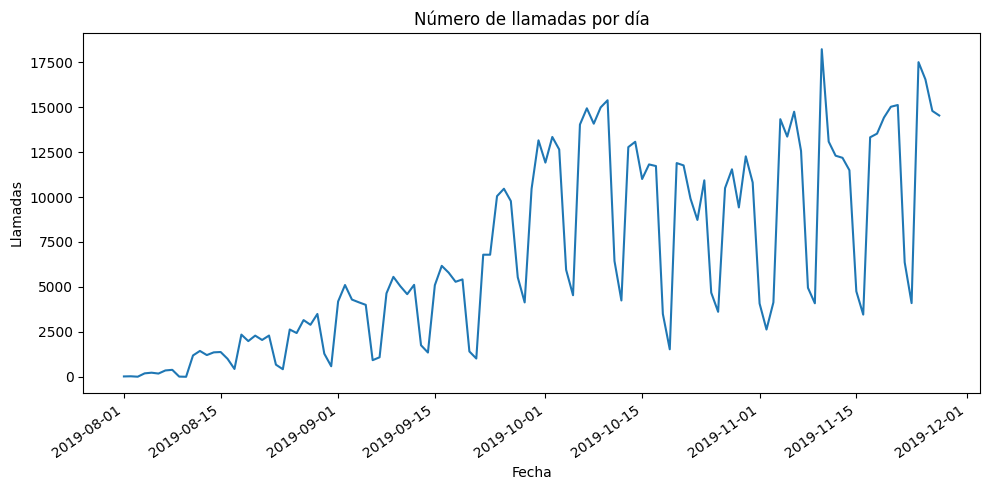

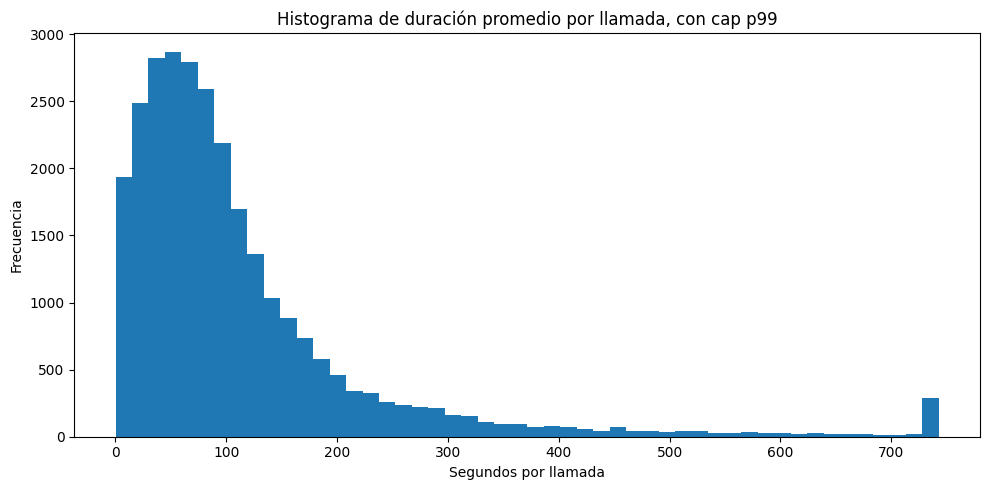

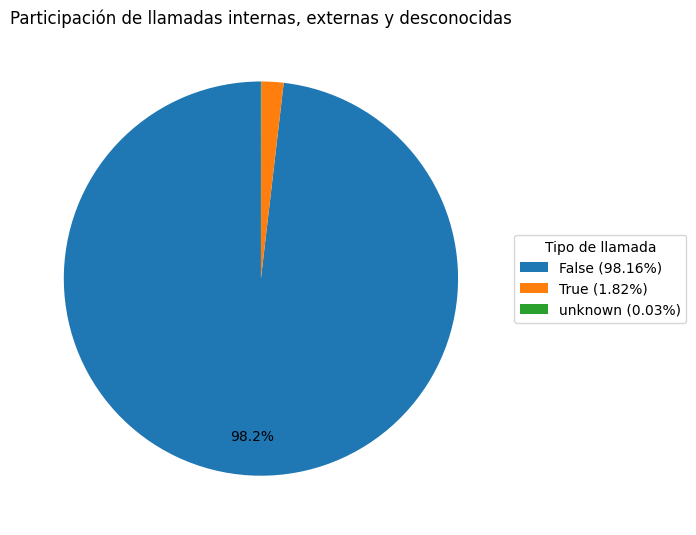

In [20]:

# Llamadas por día
calls_per_day = calls.groupby('date', as_index=False).agg(calls=('calls_count', 'sum'))

plt.figure(figsize=(10,5))
plt.plot(calls_per_day['date'], calls_per_day['calls'])
plt.title('Número de llamadas por día')
plt.xlabel('Fecha')
plt.ylabel('Llamadas')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Histograma de duración promedio de llamada, con cap en p99 para que los outliers no descompencen visualmente
duration = calls.loc[calls['avg_call_duration'] > 0, 'avg_call_duration']
cap = duration.quantile(0.99)

plt.figure(figsize=(10,5))
plt.hist(duration.clip(upper=cap), bins=50)
plt.title('Histograma de duración promedio por llamada, con cap p99')
plt.xlabel('Segundos por llamada')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Participación interno / externo
fig, ax = plt.subplots(figsize=(7, 7))

wedges, texts, autotexts = ax.pie(
    by_internal['calls'],
    autopct=lambda pct: f'{pct:.1f}%' if pct > 3 else '',  # oculta % en rebanadas diminutas
    startangle=90,
    pctdistance=0.8
)

legend_labels = [
    f"{cat} ({share:.2%})"
    for cat, share in zip(by_internal['internal'].astype(str), by_internal['share_calls'])
]
ax.legend(wedges, legend_labels, title='Tipo de llamada', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Participación de llamadas internas, externas y desconocidas')
plt.tight_layout()
plt.show()



## Criterio de identificación de operadores ineficaces

Se construyen métricas por `user_id` y `operator_id`. Para evitar que operadores con muy poca actividad distorsionen el análisis, se analizan solo operadores con:

- al menos 10 llamadas totales;
- al menos 3 días activos.

Después se marcan indicadores:

- **Alta tasa de llamadas entrantes perdidas**: tasa de llamadas perdidas de entrada por encima del percentil 75, entre operadores con al menos 10 llamadas entrantes.
- **Alta espera entrante**: espera promedio por llamada entrante por encima del percentil 75.
- **Bajo volumen saliente**: para operadores con rol saliente inferido, llamadas salientes por día por debajo del percentil 25.

Un operador se marca como ineficaz si cumple:

- alta tasa de llamadas entrantes perdidas y alta espera entrante; o
- bajo volumen saliente, si tiene rol saliente inferido.




In [15]:

op = calls.dropna(subset=['operator_id']).copy()

operator_base = op.groupby(['user_id', 'operator_id']).agg(
    total_calls=('calls_count', 'sum'),
    active_days=('date', 'nunique'),
    total_rows=('calls_count', 'size'),
    first_date=('date', 'min'),
    last_date=('date', 'max')
).reset_index()

incoming = op[op['direction'] == 'in']
incoming_agg = incoming.groupby(['user_id', 'operator_id']).agg(
    incoming_calls=('calls_count', 'sum'),
    incoming_missed_calls=('calls_count', lambda s: s[incoming.loc[s.index, 'is_missed_call']].sum()),
    incoming_wait_duration=('wait_duration', 'sum')
).reset_index()

incoming_agg['missed_rate_in'] = incoming_agg['incoming_missed_calls'] / incoming_agg['incoming_calls']
incoming_agg['avg_wait_in'] = incoming_agg['incoming_wait_duration'] / incoming_agg['incoming_calls']

outgoing = op[op['direction'] == 'out']
outgoing_agg = outgoing.groupby(['user_id', 'operator_id']).agg(
    outgoing_calls=('calls_count', 'sum'),
    outgoing_days=('date', 'nunique')
).reset_index()
outgoing_agg['out_calls_per_day'] = outgoing_agg['outgoing_calls'] / outgoing_agg['outgoing_days']

operator_metrics = (
    operator_base
    .merge(incoming_agg, on=['user_id', 'operator_id'], how='left')
    .merge(outgoing_agg, on=['user_id', 'operator_id'], how='left')
)

for col in ['incoming_calls', 'incoming_missed_calls', 'incoming_wait_duration', 'outgoing_calls', 'outgoing_days']:
    operator_metrics[col] = operator_metrics[col].fillna(0)

for col in ['missed_rate_in', 'avg_wait_in', 'out_calls_per_day']:
    operator_metrics[col] = operator_metrics[col].fillna(0)

operator_metrics['outgoing_share'] = operator_metrics['outgoing_calls'] / operator_metrics['total_calls']

display(operator_metrics.head())


,user_id,operator_id,total_calls,active_days,total_rows,first_date,last_date,incoming_calls,incoming_missed_calls,incoming_wait_duration,missed_rate_in,avg_wait_in,outgoing_calls,outgoing_days,out_calls_per_day,outgoing_share
0,166377,880020,45,14,20,2019-08-04,2019-10-02,7.0000,0.0000,54.0000,0.0000,7.7143,38.0000,7.0000,5.4286,0.8444
1,166377,880022,197,42,70,2019-08-04,2019-11-27,8.0000,0.0000,112.0000,0.0000,14.0000,189.0000,36.0000,5.2500,0.9594
2,166377,880026,2232,77,182,2019-08-06,2019-11-27,24.0000,0.0000,143.0000,0.0000,5.9583,"2,208.0000",77.0000,28.6753,0.9892
3,166377,880028,2560,78,202,2019-08-06,2019-11-27,63.0000,0.0000,343.0000,0.0000,5.4444,"2,497.0000",78.0000,32.0128,0.9754
4,166377,881278,20,5,8,2019-08-05,2019-11-24,0.0000,0.0000,0.0000,0.0000,0.0000,20.0000,5.0000,4.0000,1.0000


In [16]:

# Filtrado mínimo de actividad
active_ops = operator_metrics.query('total_calls >= 10 and active_days >= 3').copy()

inbound_population = active_ops.query('incoming_calls >= 10')
outbound_population = active_ops.query('outgoing_calls >= 10 and outgoing_days >= 3')

missed_threshold = inbound_population['missed_rate_in'].quantile(0.75)
wait_threshold = inbound_population['avg_wait_in'].quantile(0.75)
outbound_low_threshold = outbound_population['out_calls_per_day'].quantile(0.25)

active_ops['high_missed_in'] = (active_ops['incoming_calls'] >= 10) & (active_ops['missed_rate_in'] >= missed_threshold)
active_ops['high_wait_in'] = (active_ops['incoming_calls'] >= 10) & (active_ops['avg_wait_in'] >= wait_threshold)
active_ops['outbound_role'] = (active_ops['outgoing_calls'] >= 10) & (active_ops['outgoing_days'] >= 3)
active_ops['low_outbound'] = active_ops['outbound_role'] & (active_ops['out_calls_per_day'] <= outbound_low_threshold)

active_ops['ineffective_inbound'] = active_ops['high_missed_in'] & active_ops['high_wait_in']
active_ops['ineffective'] = active_ops['ineffective_inbound'] | active_ops['low_outbound']
active_ops['inefficiency_score'] = active_ops[['high_missed_in', 'high_wait_in', 'low_outbound']].sum(axis=1)

print('Umbral tasa perdida entrante p75:', round(missed_threshold, 4))
print('Umbral espera entrante p75:', round(wait_threshold, 2), 'segundos')
print('Umbral bajo outbound p25:', round(outbound_low_threshold, 2), 'llamadas salientes/día')
print('Operadores activos analizados:', len(active_ops))
print('Operadores marcados como ineficaces:', active_ops['ineffective'].sum())
print('Ineficacia por entrada:', active_ops['ineffective_inbound'].sum())
print('Bajo outbound:', active_ops['low_outbound'].sum())


Umbral tasa perdida entrante p75: 0.0166
Umbral espera entrante p75: 20.61 segundos
Umbral bajo outbound p25: 4.12 llamadas salientes/día
Operadores activos analizados: 787
Operadores marcados como ineficaces: 194
Ineficacia por entrada: 41
Bajo outbound: 163


In [17]:

top_cols = [
    'user_id', 'operator_id', 'total_calls', 'active_days',
    'incoming_calls', 'incoming_missed_calls', 'missed_rate_in', 'avg_wait_in',
    'outgoing_calls', 'out_calls_per_day', 'inefficiency_score',
    'ineffective_inbound', 'low_outbound'
]

top_ineffective = (
    active_ops[active_ops['ineffective']]
    .sort_values(['inefficiency_score', 'missed_rate_in', 'avg_wait_in'], ascending=False)
    [top_cols]
    .head(20)
)

display(top_ineffective)

active_ops.to_csv('operator_inefficiency_metrics.csv', index=False)
top_ineffective.to_csv('top_ineffective_operators.csv', index=False)


,user_id,operator_id,total_calls,active_days,incoming_calls,incoming_missed_calls,missed_rate_in,avg_wait_in,outgoing_calls,out_calls_per_day,inefficiency_score,ineffective_inbound,low_outbound
605,167580,937368,32,12,22.0000,4.0000,0.1818,24.1364,10.0000,2.5000,3,True,True
24,166407,888532,200,54,12.0000,2.0000,0.1667,24.0833,188.0000,3.6863,3,True,True
49,166503,884408,60,12,35.0000,4.0000,0.1143,26.4000,25.0000,3.5714,3,True,True
272,166946,900746,75,15,26.0000,2.0000,0.0769,23.5000,49.0000,4.0833,3,True,True
79,166536,900194,98,44,55.0000,2.0000,0.0364,21.4364,43.0000,2.0476,3,True,True
552,167497,924928,79,25,30.0000,1.0000,0.0333,32.6000,49.0000,2.5789,3,True,True
246,166916,906410,251,30,232.0000,7.0000,0.0302,26.0129,19.0000,1.9000,3,True,True
897,168155,938414,139,13,93.0000,2.0000,0.0215,23.0860,46.0000,3.8333,3,True,True
510,167445,920902,65,24,48.0000,1.0000,0.0208,44.2917,17.0000,1.8889,3,True,True
84,166541,908960,808,77,695.0000,14.0000,0.0201,23.4014,113.0000,3.0541,3,True,True


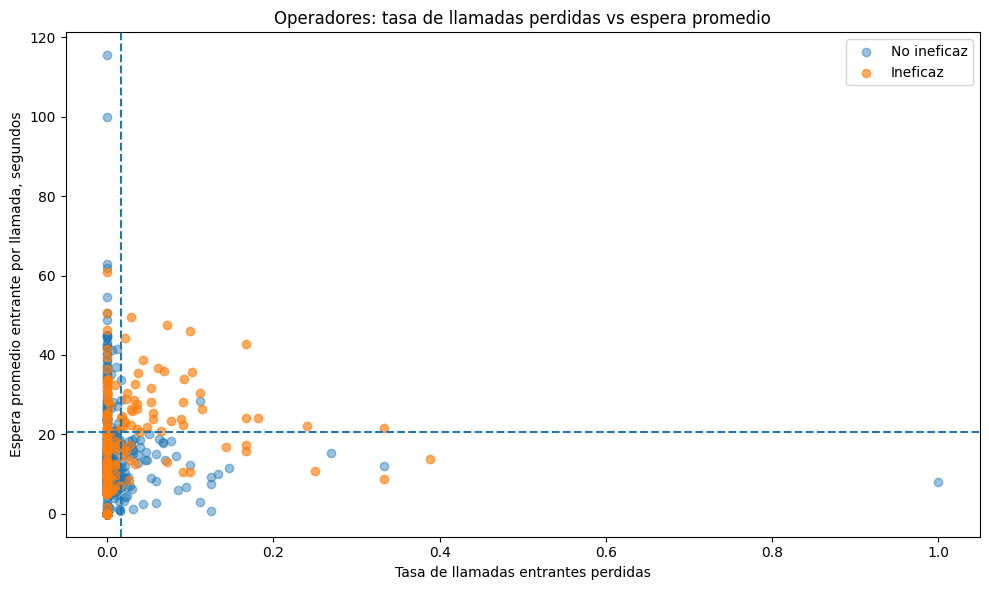

In [18]:

plt.figure(figsize=(10,6))
plt.scatter(
    active_ops.loc[~active_ops['ineffective'], 'missed_rate_in'],
    active_ops.loc[~active_ops['ineffective'], 'avg_wait_in'],
    alpha=0.45,
    label='No ineficaz'
)
plt.scatter(
    active_ops.loc[active_ops['ineffective'], 'missed_rate_in'],
    active_ops.loc[active_ops['ineffective'], 'avg_wait_in'],
    alpha=0.65,
    label='Ineficaz'
)
plt.axvline(missed_threshold, linestyle='--')
plt.axhline(wait_threshold, linestyle='--')
plt.title('Operadores: tasa de llamadas perdidas vs espera promedio')
plt.xlabel('Tasa de llamadas entrantes perdidas')
plt.ylabel('Espera promedio entrante por llamada, segundos')
plt.legend()
plt.tight_layout()
plt.show()



## Pruebas de hipótesis estadísticas

Las distribuciones de llamadas y tiempos están sesgadas y tienen outliers. Por eso se usa **Mann-Whitney U**, una prueba no paramétrica para comparar dos muestras independientes sin asumir normalidad.

Se usa `alpha = 0.05`.


In [19]:

alpha = 0.05
labels = active_ops[['user_id', 'operator_id', 'ineffective', 'low_outbound', 'outbound_role']]

# Métricas diarias de entrada por operador
daily_in = op[op['direction'] == 'in'].groupby(['user_id', 'operator_id', 'date']).agg(
    incoming_calls=('calls_count', 'sum'),
    missed=('calls_count', lambda s: s[op.loc[s.index, 'is_missed_call']].sum()),
    wait=('wait_duration', 'sum')
).reset_index()

daily_in['missed_rate'] = daily_in['missed'] / daily_in['incoming_calls']
daily_in['avg_wait'] = daily_in['wait'] / daily_in['incoming_calls']
daily_in = daily_in.merge(labels[['user_id', 'operator_id', 'ineffective']], on=['user_id', 'operator_id'], how='inner')

results = []

for metric, alternative, title in [
    ('missed_rate', 'greater', 'H1: la tasa diaria de llamadas entrantes perdidas es mayor en operadores ineficaces'),
    ('avg_wait', 'greater', 'H2: la espera diaria promedio de llamadas entrantes es mayor en operadores ineficaces')
]:
    ineffective_sample = daily_in.loc[daily_in['ineffective'], metric]
    other_sample = daily_in.loc[~daily_in['ineffective'], metric]
    test = stats.mannwhitneyu(ineffective_sample, other_sample, alternative=alternative)
    results.append({
        'hypothesis': title,
        'test': 'Mann-Whitney U',
        'mean_ineffective': ineffective_sample.mean(),
        'mean_other': other_sample.mean(),
        'p_value': test.pvalue,
        'reject_H0': test.pvalue < alpha
    })

# Métrica diaria de salida por operador outbound
out_daily = op[op['direction'] == 'out'].groupby(['user_id', 'operator_id', 'date']).agg(
    outgoing_calls=('calls_count', 'sum')
).reset_index()
out_daily = out_daily.merge(labels, on=['user_id', 'operator_id'], how='inner')
out_daily = out_daily[out_daily['outbound_role']]

low_sample = out_daily.loc[out_daily['low_outbound'], 'outgoing_calls']
other_out_sample = out_daily.loc[~out_daily['low_outbound'], 'outgoing_calls']
test = stats.mannwhitneyu(low_sample, other_out_sample, alternative='less')

results.append({
    'hypothesis': 'H3: los operadores con bajo outbound hacen menos llamadas salientes diarias que el resto de operadores outbound',
    'test': 'Mann-Whitney U',
    'mean_ineffective': low_sample.mean(),
    'mean_other': other_out_sample.mean(),
    'p_value': test.pvalue,
    'reject_H0': test.pvalue < alpha
})

stats_results = pd.DataFrame(results)
display(stats_results)
stats_results.to_csv('hypothesis_tests_results.csv', index=False)


,hypothesis,test,mean_ineffective,mean_other,p_value,reject_H0
0,H1: la tasa diaria de llamadas entrantes perdi...,Mann-Whitney U,0.0235,0.0088,0.0002,True
1,H2: la espera diaria promedio de llamadas entr...,Mann-Whitney U,21.8698,14.5537,0.0000,True
2,H3: los operadores con bajo outbound hacen men...,Mann-Whitney U,3.0415,49.8480,0.0000,True



## Conclusiones

- El dataset original contiene 53,902 filas; se eliminaron 4,900 duplicados, quedando 49,002 registros limpios.
- El periodo analizado va del 1 de agosto de 2019 al 27 de noviembre de 2019.
- Se analizaron 1,092 operadores identificados, pero el análisis de ineficacia se restringió a 787 operadores con actividad mínima suficiente.
- Se marcaron 194 operadores como potencialmente ineficaces:
  - 41 por combinación de alta tasa de llamadas entrantes perdidas y alta espera de entrada;
  - 163 por bajo volumen saliente dentro del grupo con rol saliente inferido.
- Las pruebas estadísticas apoyan que los operadores marcados como ineficaces tienen peores métricas diarias de entrada y salida que el resto.
- La recomendación principal no es despedir a nadie por una tabla. La recomendación es usar estas alertas para auditoría operativa, revisión de turnos, capacitación y validación con supervisores.

## Recomendación para producto

Crear una vista de supervisión con:

- ranking de operadores con `inefficiency_score`;
- filtros por cliente, tarifa, fecha, dirección e interno/externo;
- métricas principales: llamadas entrantes perdidas, tasa de pérdida, espera promedio, llamadas salientes por día;
- indicador de motivo: `high_missed_in`, `high_wait_in`, `low_outbound`.

## Fuentes utilizadas para el desarollo del proyecto
  1- Documentación de scipy.stats.mannwhitneyu — Resolvió qué prueba usar cuando las muestras no son normales: el test de Mann-Whitney U es la versión no paramétrica del t-test para muestras independientes, y cuando las medias de las poblaciones se distribuyen normalmente conviene usar scipy.stats.ttest_ind en su lugar. También aclaró el uso correcto del parámetro alternative para pruebas de una cola (greater/less), que es justo lo que usaste en H1, H2 y H3. SciPy

  2- Pandas User Guide – Merge, join and concatenate — Respondió cómo validar la integridad de un merge (validate='many_to_one') para asegurar que el cruce calls + clients no duplicara filas por error.

  3- Matplotlib – pie() API reference — Me dio la solución al problema de las etiquetas encimadas: los parámetros pctdistance, labeldistance y la posibilidad de pasar una función a autopct en vez de un string fijo.

  4- Verint – 5 Popular Call Center Benchmarks — Me ayudó a justificar por qué mirar tasa de llamadas perdidas y tiempo de espera juntos tiene sentido operativo: la tasa de abandono de llamadas es el porcentaje de personas que cuelgan antes de que un agente conteste, y un abandono menor al 5% se considera un buen desempeño, dándote un punto de referencia externo para contrastar contra tu umbral estadístico (percentil 75).

  5- Geckoboard – Call Abandonment Rate KPI — Reforzó la relación causal que usaste en tu criterio de ineficacia: una tasa alta de abandono suele ser resultado de tiempos de espera largos, y también puede deberse a menús IVR mal diseñados o exceso de transferencias entre departamentos. Esto respalda por qué combinaste "alta tasa de perdidas" + "alta espera" como criterio conjunto en vez de mirarlos por separado.

  6- LiveAgent – Top Call Center Industry Standard Metrics — Me dio el benchmark clásico de la industria (la regla del 80/20, donde el 80% de las llamadas debe contestarse en 20 segundos) que puedes citar en la presentación como contraste frente a tus operadores marcados como ineficaces. LiveAgent

  7- "Storytelling with Data" — Cole Nussbaumer Knaflic (storytellingwithdata.com) — Guía de referencia (no un artículo técnico) que use para estructurar la narrativa de la presentación: contexto → hallazgo → "entonces qué" (implicación de negocio).

1 https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html

2 https://pandas.pydata.org/docs/user_guide/merging.html

3 https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.pie.html

4 https://www.verint.com/blog/5-popular-call-center-benchmarks-how-do-you-stack-up/

5 https://www.geckoboard.com/resources/kpi-examples/call-abandonment-rate/

6 https://www.liveagent.com/academy/best-practices-industry-standards/
